# Transfert de Style avec le Transfer Learning
Ce notebook illustre comment appliquer le style d'une œuvre d'art à n'importe quelle photographie en utilisant un modèle de Deep Learning pré-entraîné.

In [1]:
import os
import tensorflow as tf
# Charger TensorFlow Hub pour accéder aux modèles pré-entraînés
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img

def tensor_to_image(tensor):
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

### 1. Sélection des images
Nous téléchargeons deux images : une pour le contenu et une pour le style (un tableau de Van Gogh).

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


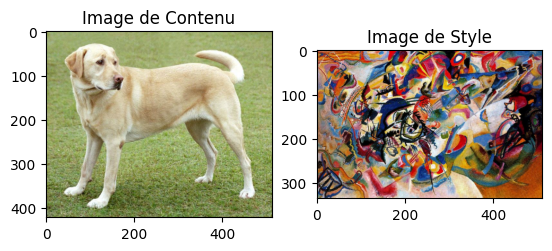

In [2]:
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky_v2.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
plt.imshow(tensor_to_image(content_image))
plt.title('Image de Contenu')

plt.subplot(1, 2, 2)
plt.imshow(tensor_to_image(style_image))
plt.title('Image de Style')
plt.show()

### 2. Chargement du modèle via TF Hub
Nous utilisons le modèle 'Arbitrary Image Stylization' qui a déjà appris à extraire les motifs de milliers de peintures.

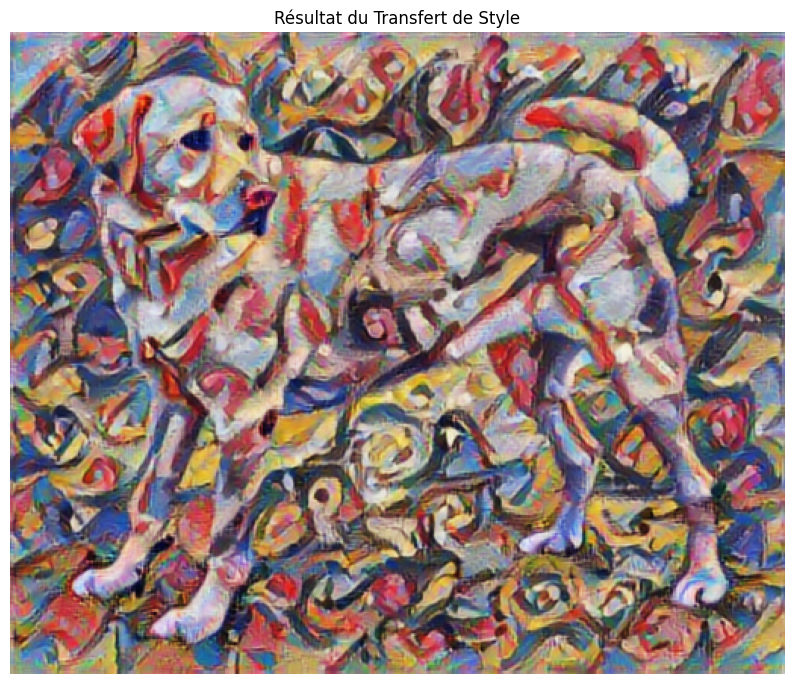

In [3]:
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

plt.figure(figsize=(10,10))
plt.imshow(tensor_to_image(stylized_image))
plt.title('Résultat du Transfert de Style')
plt.axis('off')
plt.show()